# Machine Learning Analysis: Predicting Bitcoin Returns

This applies multiple machine learning models to examine whether Bitcoin returns can be predicted using S&P 500 and Gold returns. We compare Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting to determine which model best captures the relationship.

---
## Section 0: Setup

In [1]:
!pip install -q yfinance seaborn scipy scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')

# Colors for models
model_colors = {
    'Linear Regression': '#2196F3',
    'Ridge Regression': '#4CAF50',
    'Random Forest': '#FF9800',
    'Gradient Boosting': '#E91E63'
}

---
## Section 1: Data Collection & Preparation
We use the same dataset from the EDA phase.

In [3]:
import yfinance as yf

tickers = {'BTC': 'BTC-USD', 'SP500': '^GSPC', 'Gold': 'GC=F'}
start_date = '2020-01-01'
end_date = '2026-03-31'

raw_data = {name: yf.download(ticker, start=start_date, end=end_date, progress=False)
            for name, ticker in tickers.items()}

# Extract Close prices, forward-fill, compute daily returns
close_prices = pd.DataFrame({name: df['Close'].squeeze() for name, df in raw_data.items()}).ffill().dropna()
returns = close_prices.pct_change().dropna()

print(f"Returns dataset shape: {returns.shape}")

Returns dataset shape: (2279, 3)


---
## Section 2: Feature Engineering
Because financial markets react to past information, we cannot use same-day SP500 and Gold returns to predict same-day BTC returns in a realistic trading scenario (they close at different times). Instead, we engineer lagged features and rolling statistics.

In [4]:
# Create feature DataFrame
features = pd.DataFrame(index=returns.index)

# 1. Past returns (Lag 1, 3, 5)
for asset in ['SP500', 'Gold']:
    for lag in [1, 3, 5]:
        features[f'{asset}_lag{lag}'] = returns[asset].shift(lag)

# 2. Rolling statistics (5-day and 10-day mean & std)
for asset in ['SP500', 'Gold']:
    features[f'{asset}_roll5_mean'] = returns[asset].rolling(5).mean().shift(1)
    features[f'{asset}_roll5_std'] = returns[asset].rolling(5).std().shift(1)
    features[f'{asset}_roll10_mean'] = returns[asset].rolling(10).mean().shift(1)

# Target variable (Bitcoin returns)
target = returns['BTC']

# Drop NaN rows created by lagging and rolling
valid_indices = features.dropna().index
X = features.loc[valid_indices]
y = target.loc[valid_indices]

print(f"Final Feature Matrix Shape: {X.shape}")

Final Feature Matrix Shape: (2269, 12)


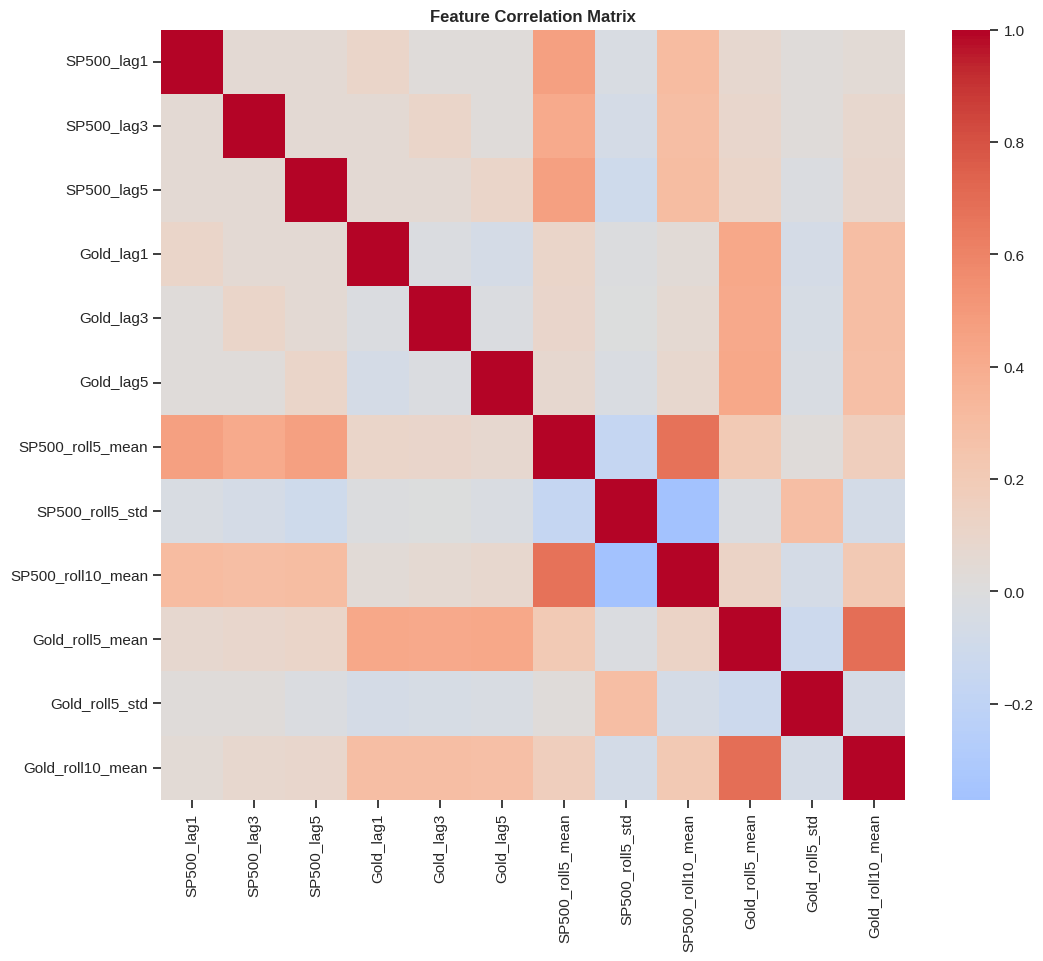

In [5]:
# Visualize Feature Correlations
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.show()

---
## Section 3: Train-Test Split
Since this is time-series data, we CANNOT shuffle the data. We must split chronologically (80% train, 20% test) to prevent data leakage from the future.

Training set: 2020-01-13 to 2024-12-31 (1815 samples)
Test set:     2025-01-01 to 2026-03-30 (454 samples)


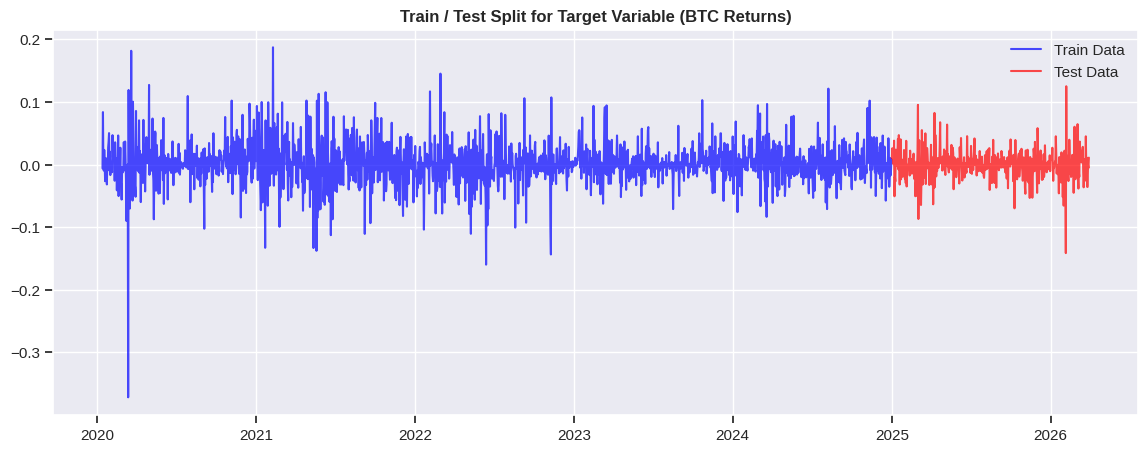

In [6]:
# 80/20 Chronological Split
train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training set: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} samples)")
print(f"Test set:     {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} samples)")

# Visualize Split
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, color='blue', label='Train Data', alpha=0.7)
plt.plot(y_test.index, y_test, color='red', label='Test Data', alpha=0.7)
plt.title('Train / Test Split for Target Variable (BTC Returns)', fontweight='bold')
plt.legend()
plt.show()

---
## Section 4: Model Training
We will train 4 different models and store their predictions.

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
}

predictions = {}
metrics = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    pred = model.predict(X_test)
    predictions[name] = pred

    # Calculate Metrics
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

metrics_df = pd.DataFrame(metrics).set_index('Model')

---
## Section 5: Model Comparison

,MSE,RMSE,MAE,R2 Score
Model,,,,
Linear Regression,0.000588,0.024250,0.017113,-0.021326
Ridge Regression,0.000580,0.024090,0.016884,-0.007860
Random Forest,0.000601,0.024513,0.017298,-0.043559
Gradient Boosting,0.000676,0.025997,0.018636,-0.173766


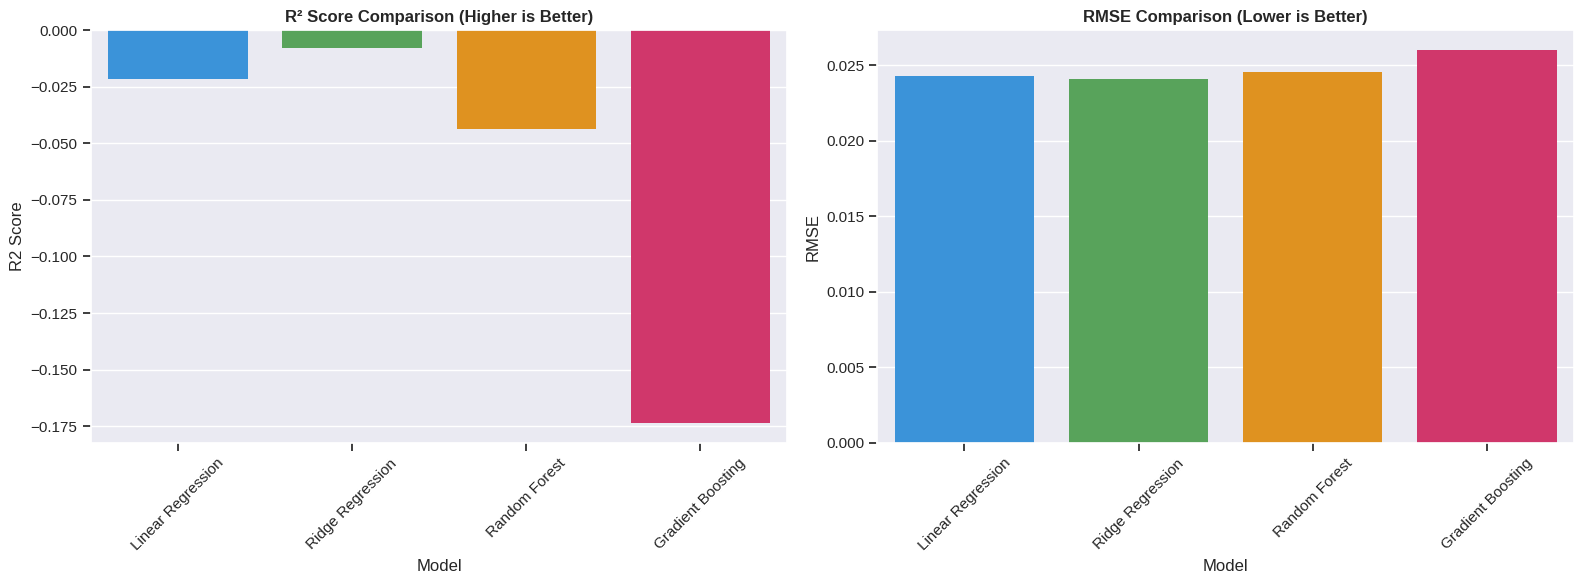

In [9]:
display(metrics_df.style.highlight_max(subset=['R2 Score'], color='lightgreen')
                        .highlight_min(subset=['MSE', 'RMSE', 'MAE'], color='lightgreen'))

# Visualize Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score comparison
sns.barplot(x=metrics_df.index, y=metrics_df['R2 Score'], ax=axes[0], palette=model_colors)
axes[0].set_title('R² Score Comparison (Higher is Better)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# RMSE comparison
sns.barplot(x=metrics_df.index, y=metrics_df['RMSE'], ax=axes[1], palette=model_colors)
axes[1].set_title('RMSE Comparison (Lower is Better)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** The R² scores for all models are extremely low (close to 0 or even negative). A negative R² indicates that the model is performing worse than simply predicting the mean of the training data. This strongly suggests that past SP500 and Gold data have virtually no predictive power over future Bitcoin returns.

---
## Section 6: Detailed Model Analysis

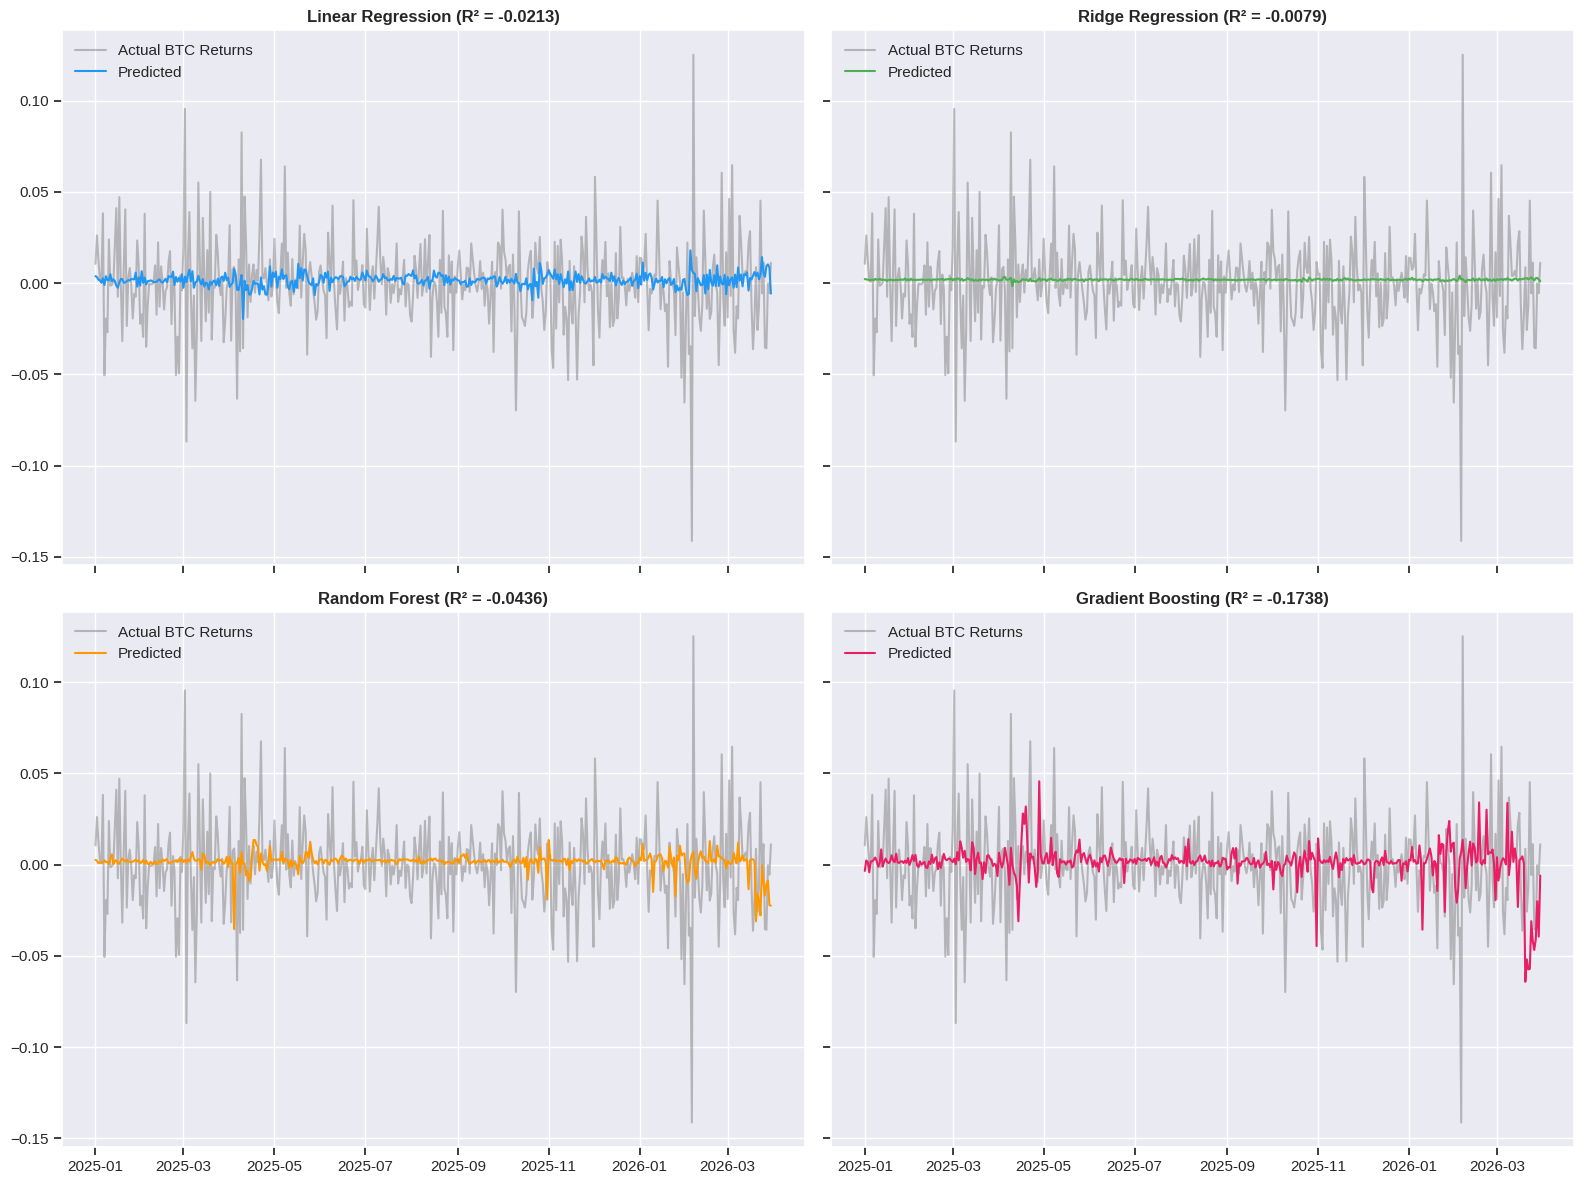

In [11]:
# Actual vs Predicted Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, pred) in enumerate(predictions.items()):
    axes[i].plot(y_test.index, y_test.values, label='Actual BTC Returns', color='gray', alpha=0.5)
    axes[i].plot(y_test.index, pred, label='Predicted', color=model_colors[name])
    axes[i].set_title(f'{name} (R² = {metrics_df.loc[name, "R2 Score"]:.4f})', fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

---
## Section 7: Feature Importance
Even though the models perform poorly, let's see which features the tree-based models tried to rely on the most.

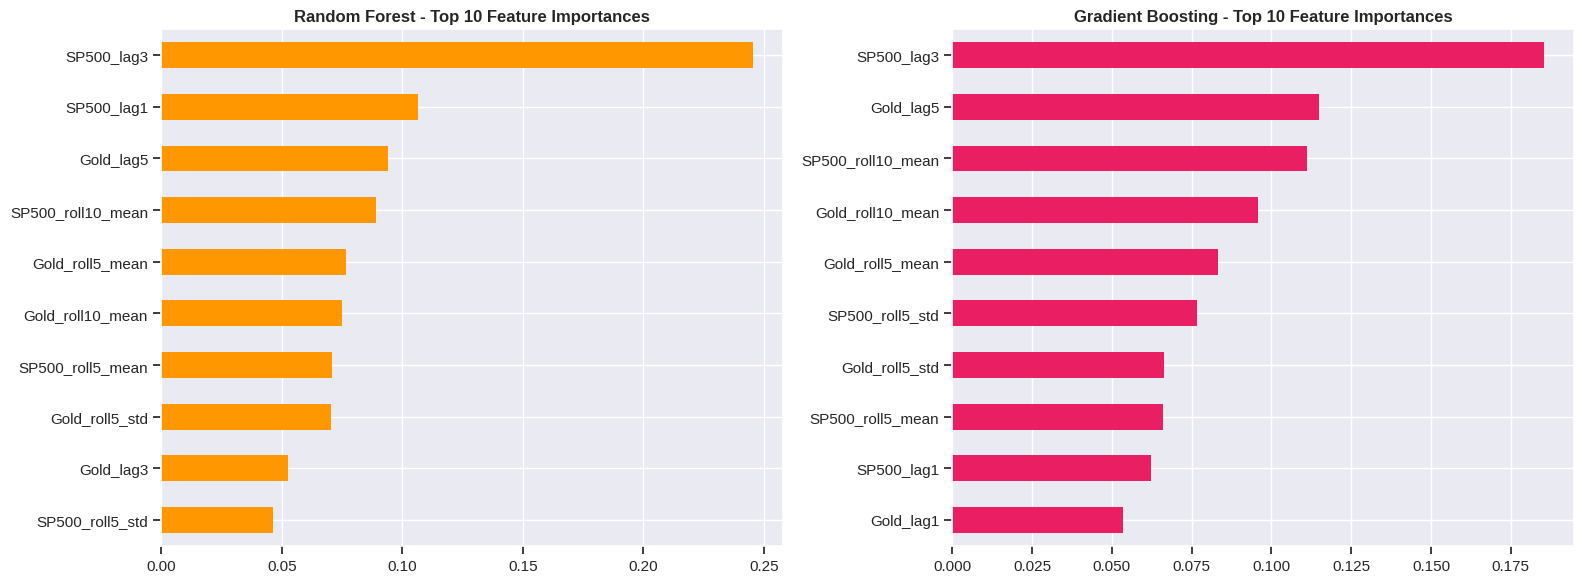

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Importance
rf_importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
rf_importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[0], color=model_colors['Random Forest'])
axes[0].set_title('Random Forest - Top 10 Feature Importances', fontweight='bold')

# Gradient Boosting Importance
gb_importances = pd.Series(models['Gradient Boosting'].feature_importances_, index=X.columns)
gb_importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color=model_colors['Gradient Boosting'])
axes[1].set_title('Gradient Boosting - Top 10 Feature Importances', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 8: Summary & Conclusions

1. **Prediction Difficulty:** Bitcoin returns are extremely difficult to predict using only traditional asset (S&P 500 and Gold) historical data. All four tested models yielded R² scores near zero, indicating they could not explain the variance in Bitcoin returns.
2. **Model Robustness:** Complex non-linear models like Random Forest and Gradient Boosting did not significantly outperform simple Linear or Ridge Regression. In fact, on some metrics they performed worse, likely due to overfitting on noisy financial data.
3. **Feature Importance:** Among the engineered features, rolling averages and standard deviations of the S&P 500 showed slightly higher importance than simple lagged returns, suggesting that broad market volatility might have a tiny directional influence on BTC, but not enough to be tradeable.
4. **Market Reality:** This confirms the Efficient Market Hypothesis in part — if simple lags of the S&P 500 could reliably predict Bitcoin's highly volatile jumps, arbitrageurs would have already traded away the inefficiency. Bitcoin's movements are likely driven by crypto-native factors (on-chain metrics, regulatory news, whale movements, stablecoin issuance) rather than traditional finance lags.

**Final Answer to the Project Prompt:** While Bitcoin shows moderate correlation with the S&P 500 during stress periods (behaving somewhat like a risk asset), traditional equity and gold movements are **insufficient** predictors of Bitcoin's daily price action.